Circuit (before measurement):



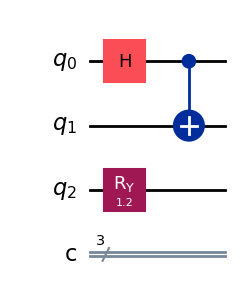


State before measurement:



<IPython.core.display.Latex object>


Circuit (with measurement):



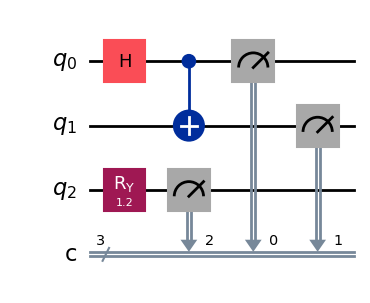


Measurement Results (counts):

{'111': 165, '011': 344, '100': 170, '000': 345}


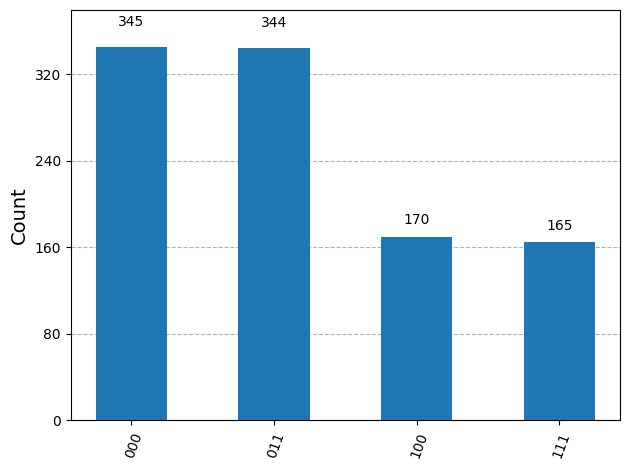

In [ ]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator
from qiskit import transpile
from qiskit.visualization import plot_histogram
from IPython.display import display

# ============================================================
# 3-QUBIT RANDOM CIRCUIT
# ============================================================

qc = QuantumCircuit(3, 3)   # 3 qubits + 3 classical bits

# Random gates
qc.h(0)
qc.cx(0, 1)
qc.ry(1.2, 2)

print("Circuit (before measurement):\n")
display(qc.draw(output='mpl'))

# ============================================================
# STATE BEFORE MEASUREMENT
# ============================================================

sv = Statevector.from_instruction(qc)

print("\nState before measurement:\n")
display(sv.draw("latex"))

# ============================================================
# ADD MEASUREMENT
# ============================================================

qc.measure([0,1,2], [0,1,2])

print("\nCircuit (with measurement):\n")
display(qc.draw(output='mpl'))

# ============================================================
# RUN / SIMULATION PART (STEP-BY-STEP)
# ============================================================

# Import simulator (virtual quantum backend)
from qiskit_aer import AerSimulator

# Create simulator object
# → This behaves like a quantum computer
sim = AerSimulator()


# ------------------------------------------------------------
# TRANSPILATION
# ------------------------------------------------------------
# Converts your circuit into a form suitable for the simulator
# (like compiling code before running)

from qiskit import transpile

compiled_circuit = transpile(qc, sim)


# ------------------------------------------------------------
# EXECUTION
# ------------------------------------------------------------
# Run the circuit on simulator
# shots = number of times experiment is repeated

job = sim.run(compiled_circuit, shots=1024)


# ------------------------------------------------------------
# GET RESULT
# ------------------------------------------------------------
# Extract result object after execution

result = job.result()


# ------------------------------------------------------------
# MEASUREMENT OUTPUT
# ------------------------------------------------------------
# Get counts of each output bitstring

counts = result.get_counts()


# ------------------------------------------------------------
# DISPLAY RESULT
# ------------------------------------------------------------
print("Measurement Counts:")
print(counts)